In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
os.makedirs("outputs", exist_ok=True)

In [5]:
# 1. بارگذاری داده از فایل اکسل

excel_path = "/.../.../Data_Ch01_Ch02.xlsx"

df = pd.read_excel(
    excel_path,
    sheet_name="Ch01_Feed_Mineralogy_Chemistry"
)

df.head()


Data shape: (200, 21)


,Sample_ID,Date,Shift,Ore_Type,Dominant_Mineral,Fe_Tot_pct,FeO_pct,Satmagan_pct,Magnetic_Factor_MF,SiO2_pct,...,CaO_pct,MgO_pct,Basicity_B2,P_pct,S_pct,Alkalis_Na2O_K2O_pct,LOI_pct,Grindability_Index,Downstream_Risk_Note,وضعیت
0,SMP-CH01-1001,2024-01-01,Shift_A,Primary Magnetite,Magnetite,66.17,23.97,60.37,91.234699,2.66,...,0.55,0.56,0.336364,0.0188,0.0364,0.0306,0.10,Medium (Wi 13.5-14.5),Standard DR-Grade; High exothermic heat during...,PASS
1,SMP-CH01-1002,2024-01-01,Shift_B,Primary Magnetite,Magnetite,68.64,26.09,65.14,94.900932,2.05,...,0.60,0.62,0.500000,0.0224,0.0236,0.0336,0.42,Medium (Wi 13.5-14.5),Standard DR-Grade; High exothermic heat during...,PASS
2,SMP-CH01-1003,2024-01-01,Shift_C,Martitic Ore,Martite / Semi-oxidized Magnetite,64.90,19.12,47.49,73.174114,4.56,...,0.53,0.64,0.222857,0.0320,0.0593,0.0567,0.82,Hard (Wi 15.5-17.0),Martitization alert: Low LIMS recovery; requir...,REJECT
3,SMP-CH01-1004,2024-01-02,Shift_A,Primary Magnetite,Magnetite,68.81,26.13,64.94,94.375817,2.87,...,0.44,0.60,0.297143,0.0131,0.0342,0.0343,0.56,Medium (Wi 13.5-14.5),Standard DR-Grade; High exothermic heat during...,PASS
4,SMP-CH01-1005,2024-01-02,Shift_B,Primary Magnetite,Magnetite,66.14,25.36,63.77,96.416692,2.57,...,0.54,0.78,0.404908,0.0265,0.0419,0.0330,0.17,Medium (Wi 13.5-14.5),Standard DR-Grade; High exothermic heat during...,PASS


In [9]:
for col in features:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"NON-NUMERIC COLUMN: {col}")
        print(df[col].dropna().unique()[:20])

NON-NUMERIC COLUMN: Grindability_Index
<ArrowStringArray>
[              'Medium (Wi 13.5-14.5)',                 'Hard (Wi 15.5-17.0)',
 'Variable / Highly Abrasive (Quartz)']
Length: 3, dtype: str


In [10]:
# ============================================
# 3. Numeric variables for Pearson correlation
# ============================================

features_numeric = [
    "Fe_Tot_pct",
    "FeO_pct",
    "Satmagan_pct",
    "Magnetic_Factor_MF",
    "SiO2_pct",
    "Al2O3_pct",
    "CaO_pct",
    "MgO_pct",
    "Basicity_B2",
    "P_pct",
    "S_pct",
    "Alkalis_Na2O_K2O_pct",
    "LOI_pct"
]

corr_matrix = df[features_numeric].corr(method="pearson")

corr_matrix

,Fe_Tot_pct,FeO_pct,Satmagan_pct,Magnetic_Factor_MF,SiO2_pct,Al2O3_pct,CaO_pct,MgO_pct,Basicity_B2,P_pct,S_pct,Alkalis_Na2O_K2O_pct,LOI_pct
Fe_Tot_pct,1.000000,0.817697,0.844512,0.788653,-0.612333,-0.694342,-0.508045,-0.327875,0.349534,-0.527165,-0.430705,-0.502795,-0.759658
FeO_pct,0.817697,1.000000,0.975330,0.972945,-0.752880,-0.825932,-0.626983,-0.410726,0.399194,-0.685794,-0.557596,-0.640690,-0.925915
Satmagan_pct,0.844512,0.975330,1.000000,0.994605,-0.751637,-0.811491,-0.638694,-0.418521,0.391267,-0.681312,-0.574211,-0.643894,-0.894842
Magnetic_Factor_MF,0.788653,0.972945,0.994605,1.000000,-0.748889,-0.804811,-0.641234,-0.420780,0.381557,-0.685100,-0.580196,-0.644869,-0.896442
SiO2_pct,-0.612333,-0.752880,-0.751637,-0.748889,1.000000,0.640906,0.489371,0.239956,-0.701944,0.530825,0.506304,0.543501,0.716875
Al2O3_pct,-0.694342,-0.825932,-0.811491,-0.804811,0.640906,1.000000,0.552314,0.381044,-0.431820,0.589938,0.478035,0.657344,0.799241
CaO_pct,-0.508045,-0.626983,-0.638694,-0.641234,0.489371,0.552314,1.000000,0.271912,-0.062551,0.505162,0.313172,0.413126,0.607224
MgO_pct,-0.327875,-0.410726,-0.418521,-0.420780,0.239956,0.381044,0.271912,1.000000,0.336453,0.309211,0.381023,0.406294,0.384189
Basicity_B2,0.349534,0.399194,0.391267,0.381557,-0.701944,-0.431820,-0.062551,0.336453,1.000000,-0.277776,-0.218475,-0.245834,-0.358120
P_pct,-0.527165,-0.685794,-0.681312,-0.685100,0.530825,0.589938,0.505162,0.309211,-0.277776,1.000000,0.335896,0.451186,0.641727


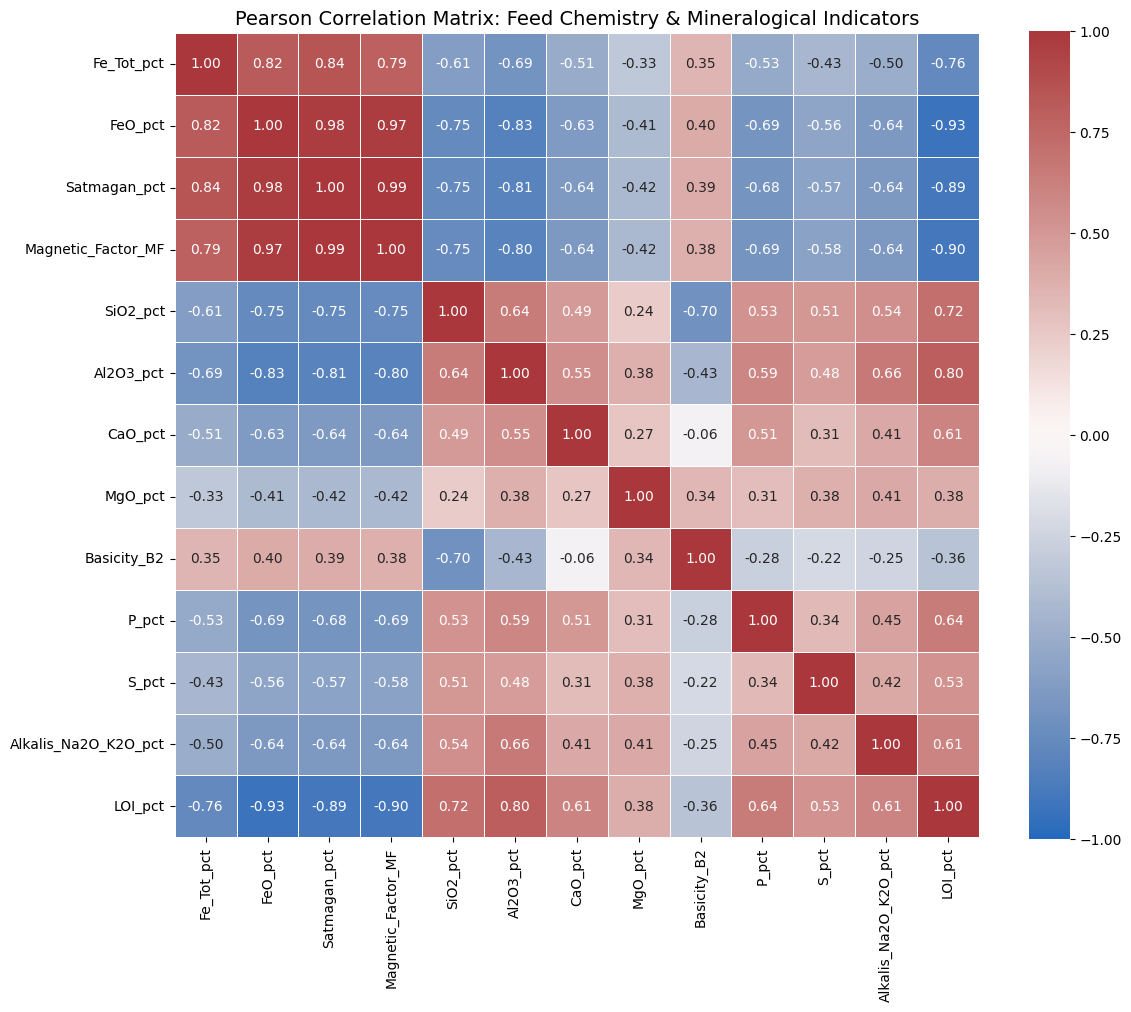

In [11]:
# ============================================
# 4. Correlation heatmap
# ============================================

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="vlag",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title(
    "Pearson Correlation Matrix: Feed Chemistry & Mineralogical Indicators",
    fontsize=14
)

plt.tight_layout()

os.makedirs("outputs", exist_ok=True)

plt.savefig(
    "outputs/ch01_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()